# **Activity: Linear filters**

Jesús David Petro Ramos - T00065696 
<!-- Aliveette Zambrano Mercado - T00067935 \ -->
Universidad Tecnológica de Bolívar

Link del repo donde he estado realizando la actividad: [Repo]()
<!-- Based on the jupyter notebook by [Vince Knight](https://github.com/drvinceknight/Python-Mathematics-Handbook) -->


In [47]:
# Importamos las librerias necesarias
from scipy.ndimage import gaussian_filter
from skimage.morphology import disk
from scipy import signal, datasets
import matplotlib.pyplot as plt
import numpy as np
import skimage

## __Brief Theory of Linear Filters__


In [6]:
def apply_gaussian_filter(img, sigma=1):
    """
    Apply a Gaussian filter to an image.

    Parameters
    ----------
    img : ndarray
        Input image.
    sigma : float, optional
        Standard deviation for Gaussian kernel (default is 1).

    Returns
    -------
    ndarray
        Smoothed image after applying Gaussian filter.
    """
    return gaussian_filter(img, sigma=sigma)


Tamaño Original: (512, 512)


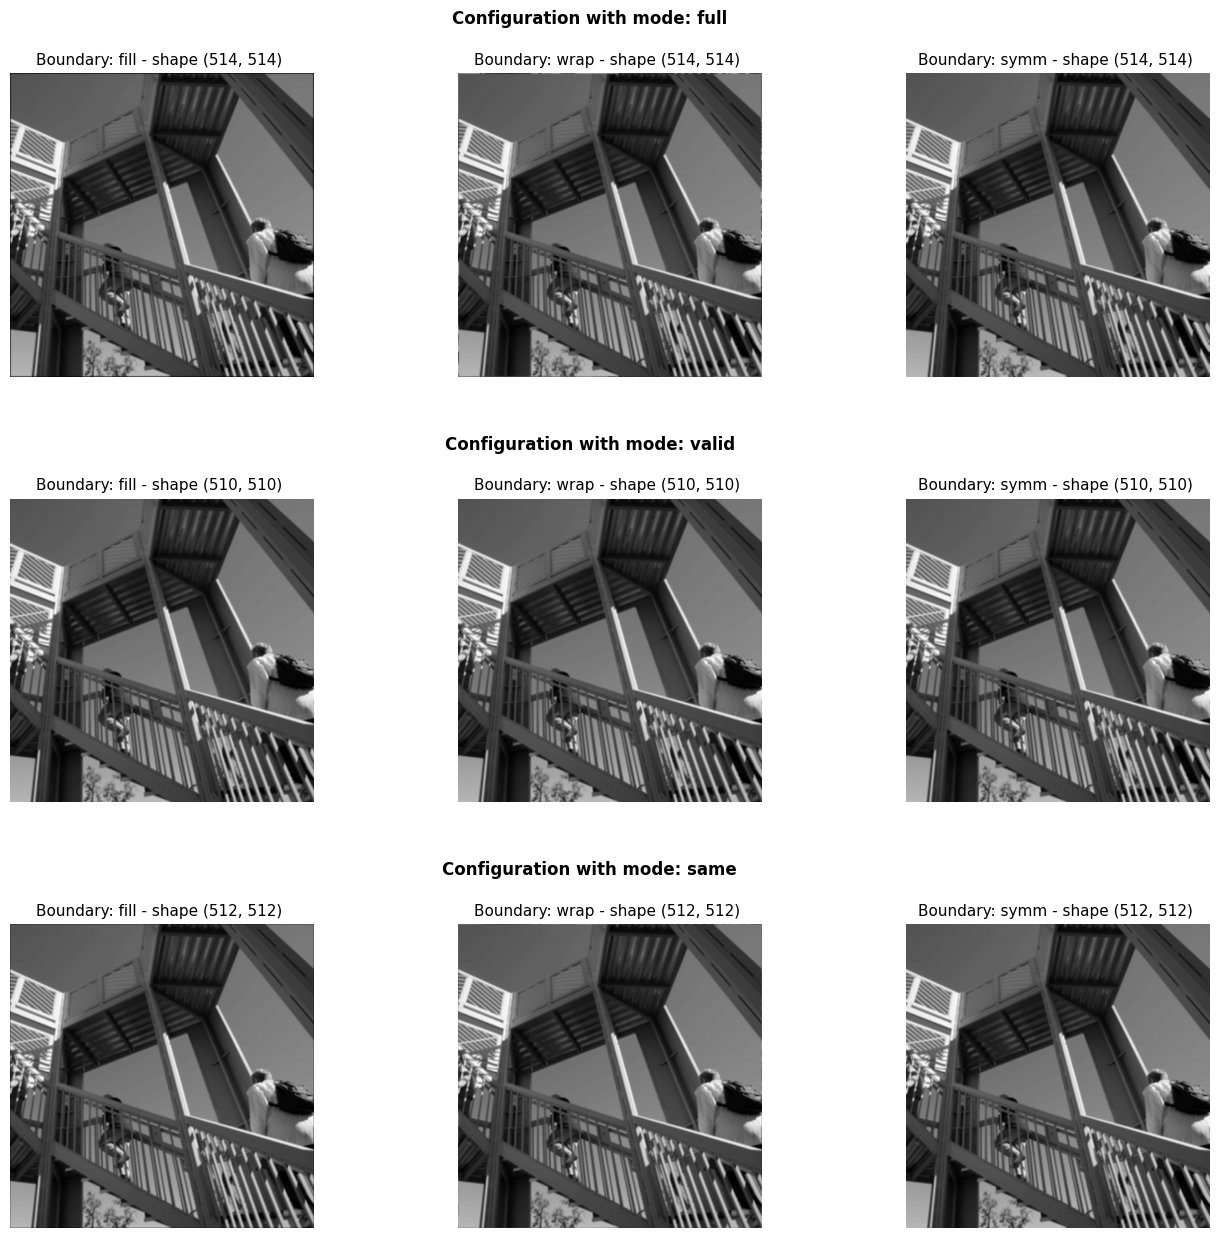

In [ ]:
# Imagen de ejemplo
img = np.uint8(datasets.ascent())
print(f'Tamaño Original: {img.shape}')

# filtro promedio de 3×3
box_fil = np.array([[1, 1, 1],
                   [1, 1, 1],
                   [1, 1, 1]]) * 1/9

# Definamos un filtro gaussiano
img_gaussian_filtered = apply_gaussian_filter(img)

#Definamos los modos y las condiciones de frontera
MODES = ['full', 'valid', 'same']
BOUNDARIES = ['fill', 'wrap', 'symm']

fig, axes = plt.subplots(3, 3, figsize=(16, 15))

# Ajustar espacio entre filas y columnas
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for mode, row in zip(MODES, axes):
    # posición superior de la fila
    y_top = max(ax.get_position().y1 for ax in row)

    # título general centrado arriba de la fila
    fig.text(0.5, y_top + 0.03, f'Configuration with mode: {mode}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Graficamos en base los boundaries y colocamos su respectivo título
    for boundary, column in zip(BOUNDARIES, row):
        img_filtered = signal.convolve2d(img, box_fil, boundary=boundary, mode = mode)
        column.imshow(img_filtered, cmap = 'gray')

        column.set_title(f'Boundary: {boundary} - shape {img_filtered.shape} ', fontsize=11)
        column.set_axis_off()

plt.show()



### **¿Cómo cambia el resultado?**

Basándonos en la documentación de [`scipy.signal.convolve2d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve2d.html), el parámetro **`mode`** define el tamaño de la salida. Existen tres opciones:

- **full**: es la opción predeterminada y devuelve la convolución completa de las entradas.  
- **valid**: solo calcula donde el kernel cabe completo en la imagen, dando una salida más pequeña.  
  Es la convolución "pura", sin relleno.
- **same**: la salida mantiene el mismo tamaño que la entrada principal, correspondiendo al resultado centrado del *full output*.  

Por otro lado, el parámetro **`boundary`** define cómo se manejan los bordes de la imagen:  

- **fill**: rellena con un valor fijo (`fillvalue`), que por defecto es 0.  
- **wrap**: aplica condiciones de contorno circulares (el final se conecta con el inicio).  
- **symm**: utiliza condiciones de contorno simétricas, reflejando los bordes.  

---

### **Influencia de la combinación**

La combinación de ambos parámetros determina el aspecto final de la convolución:

- El **`mode`** controla principalmente el **tamaño de la salida** (más grande con *full*, igual que la entrada con *same*, o más pequeño con *valid*).  
- El **`boundary`** influye en **cómo se calculan los píxeles de los bordes**:  
  - Con *fill* se generan bordes oscurecidos o distorsionados por el relleno con ceros.  
  - Con *wrap* la imagen se comporta como si estuviera “enrollada”, por lo que patrones en un borde se repiten en el opuesto.  
  - Con *symm* los bordes se suavizan reflejando los valores cercanos, lo cual suele dar transiciones más naturales.  

En conjunto, elegir un `mode` u otro afecta a la **dimensión del resultado**, mientras que `boundary` modifica la **apariencia y continuidad de los bordes** en la convolución.


## __Experiment with Different Types of Noise AND Applying a Median Filter to Remove Noise__ 

In [65]:
def plot_noise_filters(noise_list, img):
    """
    Plot images with different types of noise and apply filters.

    Parameters
    ----------
    noise_list : list of str
        List of noise modes supported by skimage.util.random_noise.
    img : ndarray
        Input image (2D grayscale) to apply noise and filters.

    Returns
    -------
    None
        Displays a matplotlib figure with noisy images and filtered results.
    """
    fig, axes = plt.subplots(min(len(noise_list), 4), 3, figsize=(16, 5 * len(noise_list)))
    plt.subplots_adjust(hspace=0.25, wspace=0.3)
    
    for noise, row in zip(noise_list, axes):
        # Position of the top of the row for placing a general title
        y_top = max(ax.get_position().y1 for ax in row)

        # General row title
        fig.text(0.5, y_top + 0.02, f'Mode: {noise}',
                 ha='center', va='bottom', fontsize=14, fontweight='bold')

        # Generate noisy image
        img_noise = skimage.util.random_noise(img, mode=noise)
        img_noise = np.uint8(img_noise * 255)

        # Apply filters
        img_gaussian = apply_gaussian_filter(img_noise)
        img_med = skimage.filters.median(img_noise, disk(2))

        # Column 1: noisy image
        row[0].imshow(img_noise, cmap='gray')
        row[0].set_title(f'Noise: {noise}', fontsize=12)
        row[0].axis('off')

        # Column 2: Gaussian filter
        row[1].imshow(img_gaussian, cmap='gray')
        row[1].set_title('Gaussian filter', fontsize=12)
        row[1].axis('off')

        # Column 3: Median filter
        row[2].imshow(img_med, cmap='gray')
        row[2].set_title('Median filter', fontsize=12)
        row[2].axis('off')

    plt.show()

In [58]:
print(disk(2))

[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]]


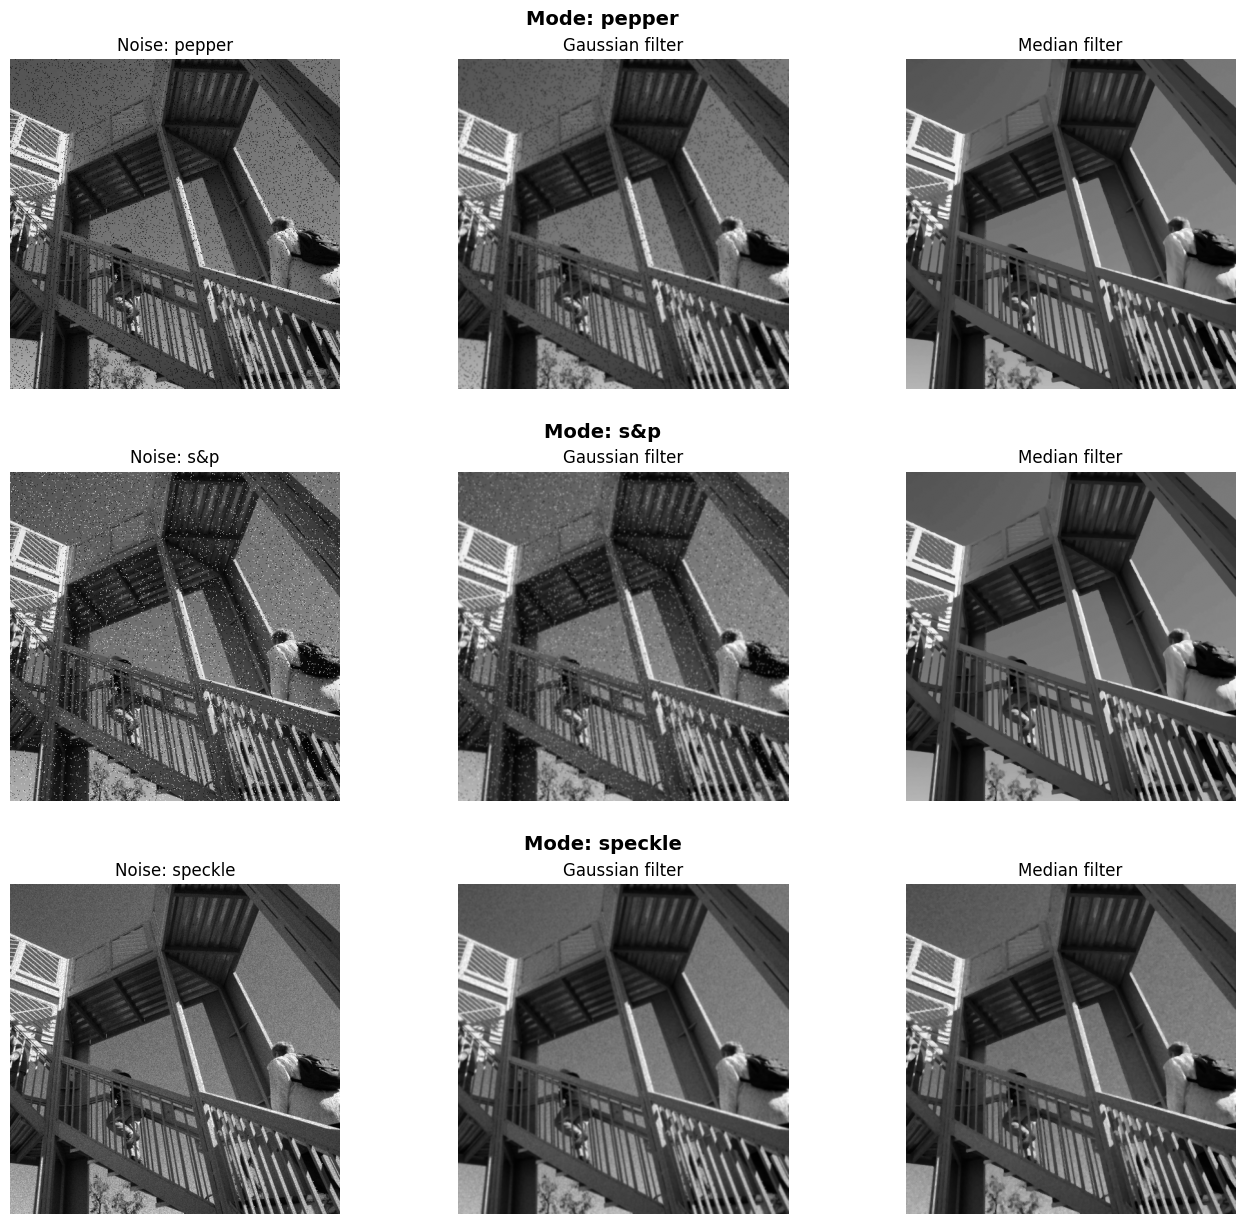

In [66]:
NOISE = ['pepper', 's&p', 'speckle']
plot_noise_filters(NOISE, img)

## __More Types of Noise__


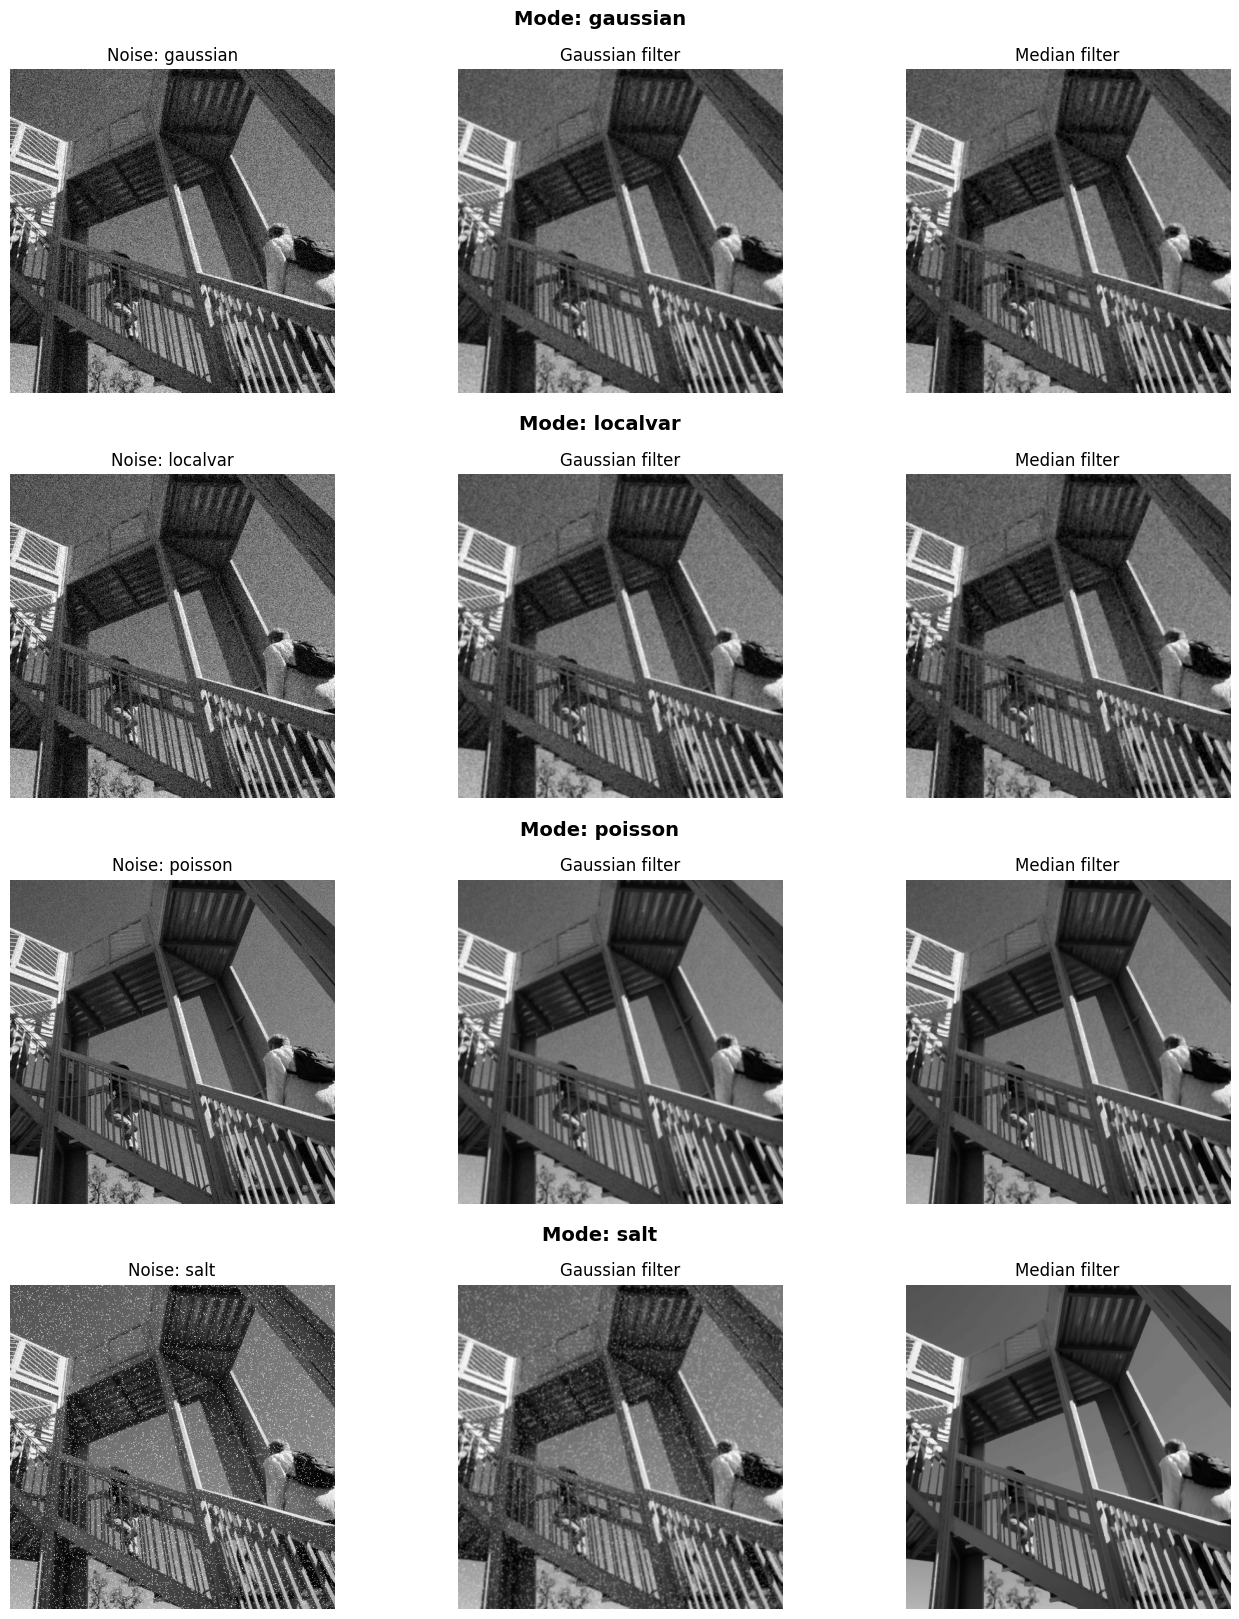

In [67]:
NOISE = ['gaussian', 'localvar', 'poisson', 'salt']
plot_noise_filters(NOISE, img)

## __Further Exploration__

In [ ]:
# TODO try other filters
# Prewit, Sobel, unsharp, laplacian

## TODO: Discussion and Conclusions

In this final section, you are tasked with synthesizing your findings and insights from the various exercises and explorations you've conducted. Reflect on what you've learned and draw meaningful conclusions. Here's a guide to help structure your discussion and conclusions:

### 1. Understanding of Linear Filters
- Discuss your newfound understanding of linear filters, their mathematical foundations, and how they operate on images.
- Explain the differences and similarities between various types of linear filters such as low-pass, high-pass, band-pass filters, and their applications.

### 2. Non-Linear Filters
- Reflect on the use of non-linear filters like the median filter. How do they compare to linear filters, and in what scenarios might they be preferred?

### 3. Noise Reduction and Edge Detection
- Analyze the effectiveness of different filters in reducing various types of noise.
- Discuss the role of filters like Prewitt, Sobel, unsharp, and Laplacian in edge detection and image enhancement.

### 4. Practical Considerations
- What are the practical considerations when choosing and implementing these filters? Consider aspects such as computational efficiency, suitability for specific tasks, etc.

### 5. Real-World Applications
- Provide examples or hypothesize scenarios where these filtering techniques could be applied in real-world situations. Relate this to fields you are familiar with, such as medical imaging or computer vision.

### 6. Reflection on Challenges and Learning
- Reflect on any challenges you faced during the exercises and how you overcame them.
- What were the key takeaways, and how might this knowledge benefit your future studies or career?

### 7. Suggestions for Further Exploration
- Suggest areas for further exploration or topics you found particularly intriguing. How might you continue to explore these topics in future projects or coursework?

### Guidance
- Be concise yet comprehensive in your discussion.
- Support your statements with specific examples and observations from the exercises.
- Feel free to include visual comparisons or code snippets if they enhance your explanation.

Your discussion and conclusions should demonstrate a deep understanding of the topics covered and articulate how these concepts are interconnected and relevant to broader fields of study. This section will likely serve as a valuable reference for your future work in image processing and related disciplines.
